# **Data Visualization**


## Objectives


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 166.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 169.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 177.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 177.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 171.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [2]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [3]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [4]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Running an SQL Query


Count the number of rows in the table named 'main'


In [5]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Listing All Tables


To view the names of all tables in the database:


In [6]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Describing a table

Use this query to get the schema of a specific table, main in this case:


In [8]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [9]:
df = pd.read_csv('survey-data.csv')

In [10]:
print('CompTotal' in df.columns)

True

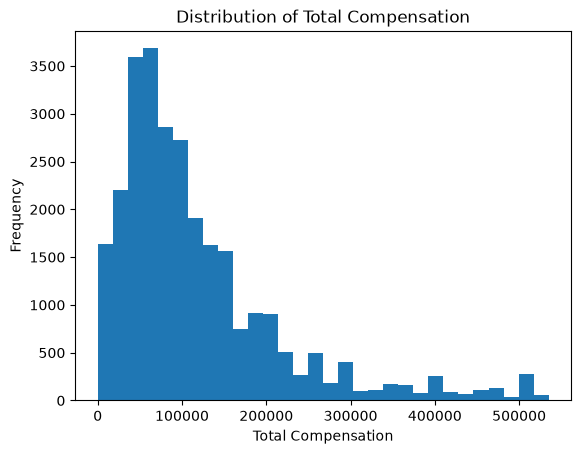

In [12]:
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df_comp = pd.read_sql_query(QUERY, conn)

# Remove extreme outliers
Q1 = df_comp['CompTotal'].quantile(0.25)
Q3 = df_comp['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

df_comp_clean = df_comp[
    (df_comp['CompTotal'] >= Q1 - 1.5 * IQR) &
    (df_comp['CompTotal'] <= Q3 + 1.5 * IQR)
]

df_comp_clean['CompTotal'].plot(kind='hist', bins=30)

plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.title('Distribution of Total Compensation')
plt.show()

**Box Plots**

Plot a box plot of Age.


In [16]:
age_midpoints = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 65,
    'Prefer not to say': None
}


In [17]:
time_midpoints = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

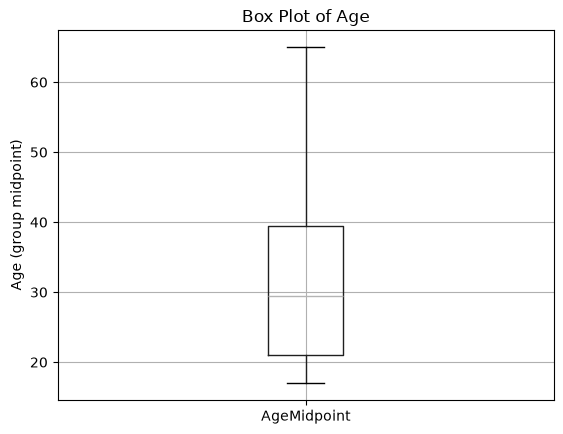

In [18]:
QUERY = "SELECT Age FROM main"
df_age = pd.read_sql_query(QUERY, conn)
df_age['AgeMidpoint'] = df_age['Age'].map(age_midpoints)
df_age[['AgeMidpoint']].boxplot()
plt.ylabel('Age (group midpoint)'); plt.title('Box Plot of Age'); plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


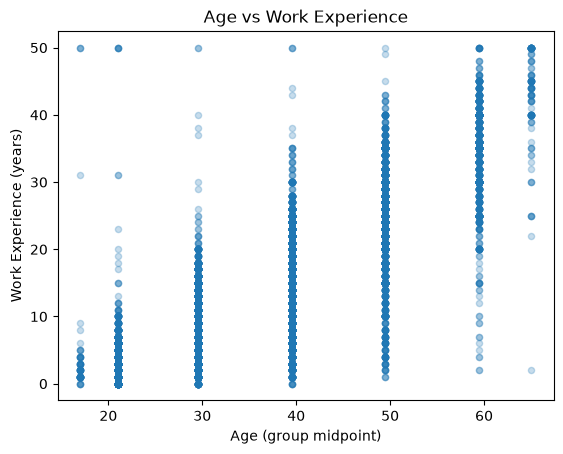

In [19]:
QUERY = """SELECT Age, WorkExp FROM main
WHERE Age IS NOT NULL AND WorkExp IS NOT NULL"""
df_scat = pd.read_sql_query(QUERY, conn)
df_scat['AgeMidpoint'] = df_scat['Age'].map(age_midpoints)
df_scat.plot(kind='scatter', x='AgeMidpoint', y='WorkExp', alpha=0.25)
plt.xlabel('Age (group midpoint)'); plt.ylabel('Work Experience (years)')
plt.title('Age vs Work Experience'); plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


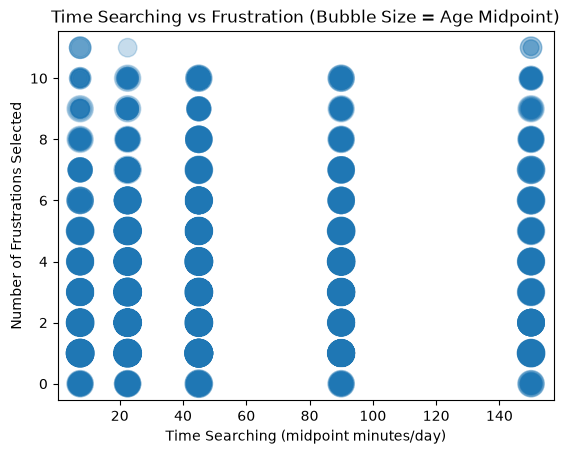

In [20]:
QUERY = "SELECT Age, TimeSearching, Frustration FROM main"
df_bubble = pd.read_sql_query(QUERY, conn)
df_bubble['AgeMidpoint'] = df_bubble['Age'].map(age_midpoints)
df_bubble['TimeSearchingMinutes'] = df_bubble['TimeSearching'].map(time_midpoints)
df_bubble['FrustrationCount'] = df_bubble['Frustration'].fillna('').apply(
    lambda x: 0 if str(x).strip() == '' else len([v for v in str(x).split(';') if v.strip()])
)
plot_df = df_bubble.dropna(subset=['AgeMidpoint', 'TimeSearchingMinutes'])
plt.scatter(plot_df['TimeSearchingMinutes'], plot_df['FrustrationCount'],
            s=plot_df['AgeMidpoint'] * 6, alpha=0.25)
plt.xlabel('Time Searching (midpoint minutes/day)')
plt.ylabel('Number of Frustrations Selected')
plt.title('Time Searching vs Frustration (Bubble Size = Age Midpoint)')
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


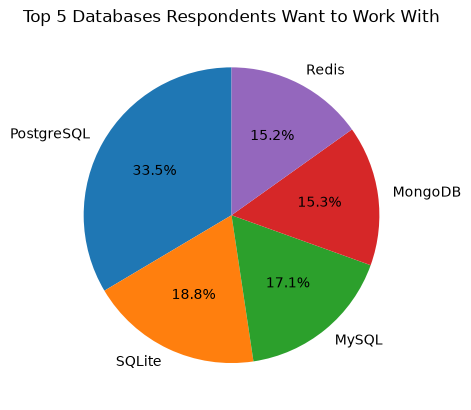

In [21]:
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)
db_counts = df_db['DatabaseWantToWorkWith'].str.split(';').explode().str.strip().value_counts().head(5)
plt.pie(db_counts.values, labels=db_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Databases Respondents Want to Work With'); plt.show()

**Stacked Charts** 

Create a stacked bar chart of median TimeSearching and TimeAnswering for the age group 25 to 34.


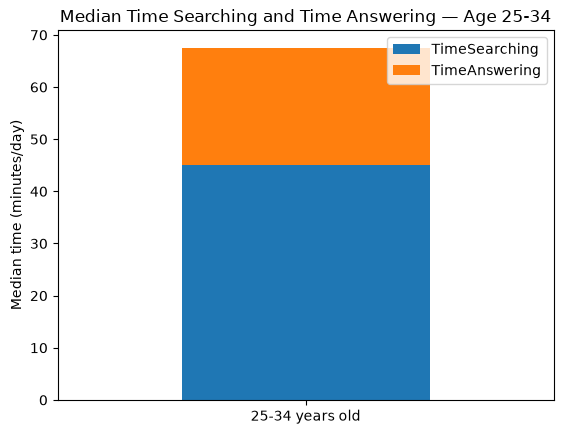

In [22]:
QUERY = """SELECT Age, TimeSearching, TimeAnswering
FROM main WHERE Age = '25-34 years old'"""
df_stack = pd.read_sql_query(QUERY, conn)
df_stack['TimeSearchingMinutes'] = df_stack['TimeSearching'].map(time_midpoints)
df_stack['TimeAnsweringMinutes'] = df_stack['TimeAnswering'].map(time_midpoints)
medians = pd.DataFrame({
    'TimeSearching': [df_stack['TimeSearchingMinutes'].median()],
    'TimeAnswering': [df_stack['TimeAnsweringMinutes'].median()]
}, index=['25-34 years old'])
medians.plot(kind='bar', stacked=True)
plt.ylabel('Median time (minutes/day)')
plt.title('Median Time Searching and Time Answering — Age 25-34')
plt.xticks(rotation=0); plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


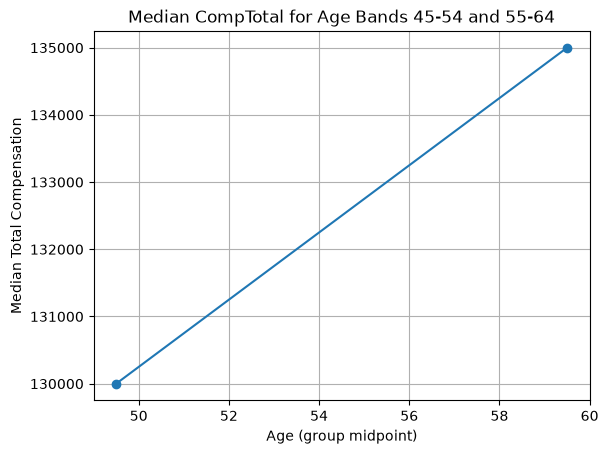

In [23]:
QUERY = """SELECT Age, CompTotal FROM main
WHERE Age IN ('45-54 years old', '55-64 years old') AND CompTotal IS NOT NULL"""
df_line = pd.read_sql_query(QUERY, conn)
df_line['AgeMidpoint'] = df_line['Age'].map(age_midpoints)
median_comp = df_line.groupby('AgeMidpoint')['CompTotal'].median().sort_index()
median_comp.plot(kind='line', marker='o')
plt.xlabel('Age (group midpoint)'); plt.ylabel('Median Total Compensation')
plt.title('Median CompTotal for Age Bands 45-54 and 55-64')
plt.grid(True); plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


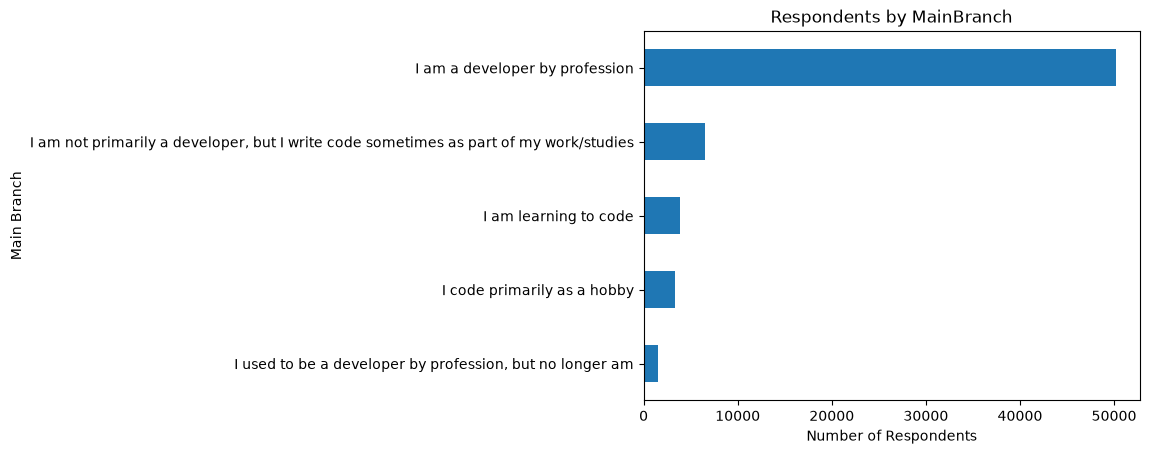

In [22]:
QUERY = """SELECT MainBranch, COUNT(*) AS Count FROM main
WHERE MainBranch IS NOT NULL GROUP BY MainBranch ORDER BY Count"""
df_branch = pd.read_sql_query(QUERY, conn)
df_branch.plot(kind='barh', x='MainBranch', y='Count', legend=False)
plt.xlabel('Number of Respondents'); plt.ylabel('Main Branch')
plt.title('Respondents by MainBranch'); plt.show()

### Summary


- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection


In [24]:
conn.close()